In [1]:
# Import essential libraries for data analysis and machine learning
import numpy as np  # Numerical operations and array manipulation
import pandas as pd  # Data manipulation and analysis
import seaborn as sns  # Statistical data visualization
import matplotlib.pyplot as plt  # Plotting and visualization
import warnings
warnings.filterwarnings('ignore')  # Suppress warning messages for cleaner output

In [2]:
# Load the heart disease dataset from CSV file
df = pd.read_csv("heart.csv")
# This dataset contains medical information for heart disease prediction
# Features include age, sex, chest pain type, blood pressure, cholesterol, etc.

In [3]:
# Display the first 5 rows of the dataset to understand its structure
df.head()
# This gives us a preview of the data including:
# Age, Sex, ChestPainType, RestingBP (blood pressure), Cholesterol, 
# FastingBS (fasting blood sugar), RestingECG, MaxHR (max heart rate),
# ExerciseAngina, Oldpeak, ST_Slope, and HeartDisease (target variable)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# Exploratory Data Analysis (EDA) - Understanding the data structure and patterns

In [4]:
# Display all column names in the dataset
df.columns
# This helps us understand all available features for analysis

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [5]:
# Check the dimensions of the dataset (rows, columns)
df.shape
# Returns (918, 12) meaning 918 patients/records and 12 features/variables

(918, 12)

In [6]:
# Get detailed information about the dataset including:
# - Data types of each column
# - Non-null count for each column
# - Memory usage
df.info()
# This helps identify data types, missing values, and overall dataset structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
# Generate descriptive statistics for numerical columns
df.describe()
# Provides key metrics including:
# - Count: number of non-null values
# - Mean: average value
# - Std: standard deviation (measure of spread)
# - Min/Max: minimum and maximum values
# - 25%/50%/75%: quartiles (percentiles)
# This helps identify outliers and understand data distribution

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
# Check for duplicate rows in the dataset
df.duplicated().sum()
# Returns 0, indicating no duplicate records exist
# Duplicates can bias model training and affect analysis accuracy

np.int64(0)

<Axes: xlabel='HeartDisease'>

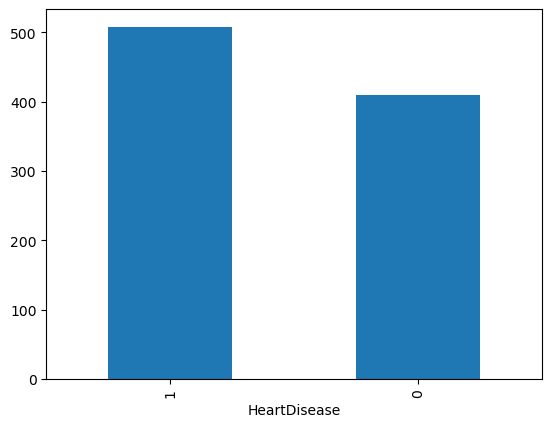

In [9]:
# Visualize the distribution of the target variable (HeartDisease)
df['HeartDisease'].value_counts().plot(kind = "bar")
# This bar chart shows the balance between:
# 0: No heart disease
# 1: Heart disease present
# Important for understanding class balance in classification problems

In [10]:
# Check for missing values in each column
df.isnull().sum()
# All columns show 0 missing values, indicating a complete dataset
# Missing values need to be handled before machine learning modeling

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

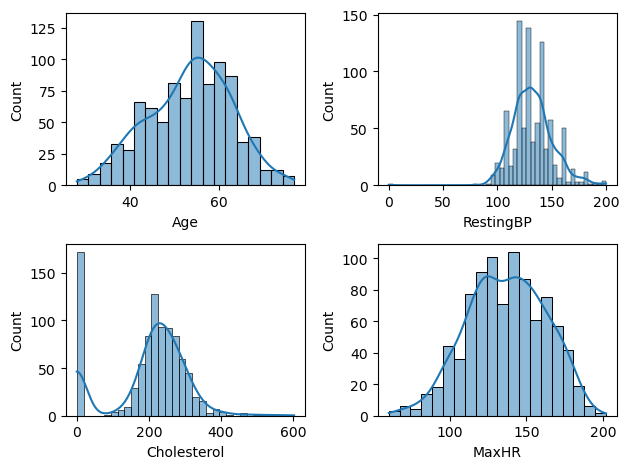

In [11]:
# Create a function to plot distribution of numerical variables
def plotting(var, num):
    plt.subplot(2, 2, num)  # Create subplot in a 2x2 grid
    sns.histplot(df[var], kde=True)  # Plot histogram with KDE (kernel density estimate)
    # KDE shows the probability density function of the data

# Plot distributions for key numerical features
plotting('Age', 1)        # Age distribution
plotting('RestingBP', 2)  # Resting blood pressure distribution  
plotting('Cholesterol', 3) # Cholesterol level distribution
plotting('MaxHR', 4)      # Maximum heart rate distribution

plt.tight_layout()  # Adjust subplot parameters for tight layout

In [12]:
# Analyze cholesterol values to identify potential data quality issues
df['Cholesterol'].value_counts()
# We can see 172 records have cholesterol value of 0, which is medically unrealistic
# This indicates missing or erroneous data that needs to be handled

Cholesterol
0      172
254     11
223     10
220     10
230      9
      ... 
392      1
316      1
153      1
466      1
131      1
Name: count, Length: 222, dtype: int64

In [13]:
# Calculate the mean cholesterol value excluding zero values
ch_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()
# This will be used to replace unrealistic zero cholesterol values
# Using mean imputation is a common approach for handling missing/erroneous data

In [14]:
# Replace zero cholesterol values with the calculated mean
df['Cholesterol'] = df['Cholesterol'].replace(0, ch_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)  # Round to 2 decimal places
# This data cleaning step ensures realistic cholesterol values for better model performance

In [15]:
# Handle zero values in Resting Blood Pressure (RestingBP) column
resting_bp_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()

df['RestingBP'] = df['RestingBP'].replace(0, resting_bp_mean)
df['RestingBP'] = df['RestingBP'].round(2)
# Similar to cholesterol, zero blood pressure values are unrealistic and need imputation
# This ensures data quality for accurate modeling

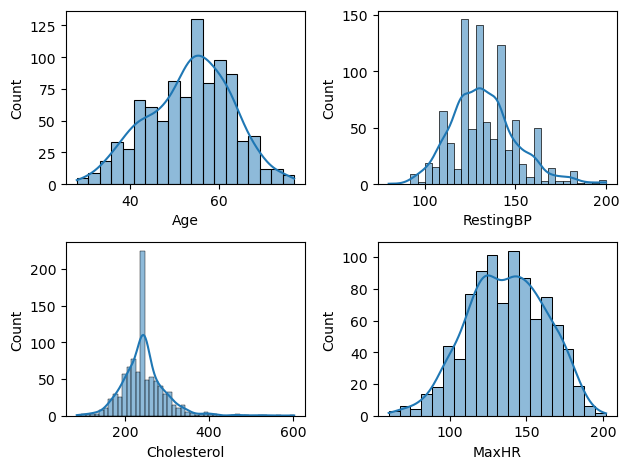

In [16]:
# Re-plot the distributions after data cleaning to see improvements
def plotting(var, num):
    plt.subplot(2, 2, num)
    sns.histplot(df[var], kde=True)

plotting('Age', 1)        # Age distribution (unchanged)
plotting('RestingBP', 2)  # Resting BP distribution (now without zeros)
plotting('Cholesterol', 3) # Cholesterol distribution (now without zeros)
plotting('MaxHR', 4)      # Max HR distribution (unchanged)

plt.tight_layout()
# Comparing with previous plots shows the impact of data cleaning

In [17]:
# Install sheryanalysis package for automated data analysis
pip install sheryanalysis==0.1.0
# This package provides quick and comprehensive data analysis reports

SyntaxError: invalid syntax (2139614416.py, line 2)

In [ ]:
# Use sheryanalysis package for comprehensive automated data analysis
import sheryanalysis as sh  
sh.analyze(df)
# This provides:
# - Dataset shape and basic statistics
# - Column categorization (numerical, categorical, datetime, text)
# - Null value analysis
# - Data type information
# Quick overview of dataset structure and quality


🔍 Basic Analysis Report
------------------------------------------------------------
📏 Shape: (918, 12)
🧱 Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']

✅ No null values found

🔠 Categorical Columns: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']

🔢 Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


{'shape': (918, 12),
 'columns': ['Age',
  'Sex',
  'ChestPainType',
  'RestingBP',
  'Cholesterol',
  'FastingBS',
  'RestingECG',
  'MaxHR',
  'ExerciseAngina',
  'Oldpeak',
  'ST_Slope',
  'HeartDisease'],
 'dtypes': {'Age': dtype('int64'),
  'Sex': dtype('O'),
  'ChestPainType': dtype('O'),
  'RestingBP': dtype('float64'),
  'Cholesterol': dtype('float64'),
  'FastingBS': dtype('int64'),
  'RestingECG': dtype('O'),
  'MaxHR': dtype('int64'),
  'ExerciseAngina': dtype('O'),
  'Oldpeak': dtype('float64'),
  'ST_Slope': dtype('O'),
  'HeartDisease': dtype('int64')},
 'null_counts': {'Age': 0,
  'Sex': 0,
  'ChestPainType': 0,
  'RestingBP': 0,
  'Cholesterol': 0,
  'FastingBS': 0,
  'RestingECG': 0,
  'MaxHR': 0,
  'ExerciseAngina': 0,
  'Oldpeak': 0,
  'ST_Slope': 0,
  'HeartDisease': 0},
 'total_rows': 918,
 'column_types': {'categorical': ['Sex',
   'ChestPainType',
   'FastingBS',
   'RestingECG',
   'ExerciseAngina',
   'ST_Slope',
   'HeartDisease'],
  'numerical': ['Age', 'Rest

<Axes: xlabel='Sex', ylabel='count'>

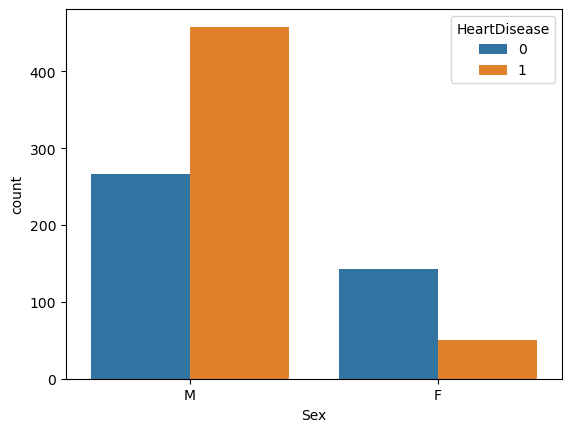

In [ ]:
# Visualize heart disease distribution by gender
sns.countplot(x=df['Sex'], hue=df['HeartDisease'])
# This shows:
# - How many males vs females have heart disease
# - Gender-based patterns in heart disease occurrence
# Helps identify if gender is a significant risk factor

<Axes: xlabel='ChestPainType', ylabel='count'>

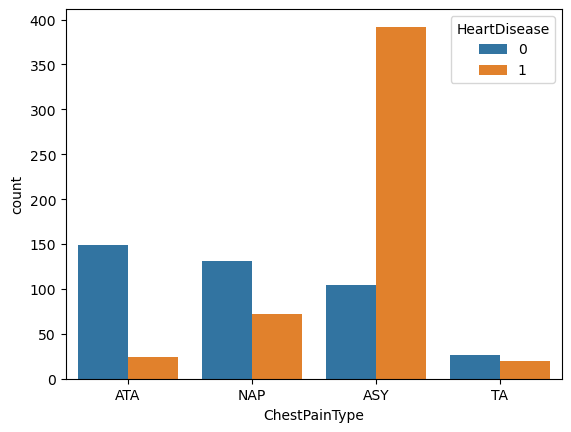

In [ ]:
# Visualize heart disease distribution by chest pain type
sns.countplot(x=df['ChestPainType'], hue=df['HeartDisease'])
# Chest pain types include:
# - ATA: Atypical Angina
# - NAP: Non-Anginal Pain  
# - ASY: Asymptomatic
# - TA: Typical Angina
# This helps identify which chest pain types are more associated with heart disease

<Axes: xlabel='FastingBS', ylabel='count'>

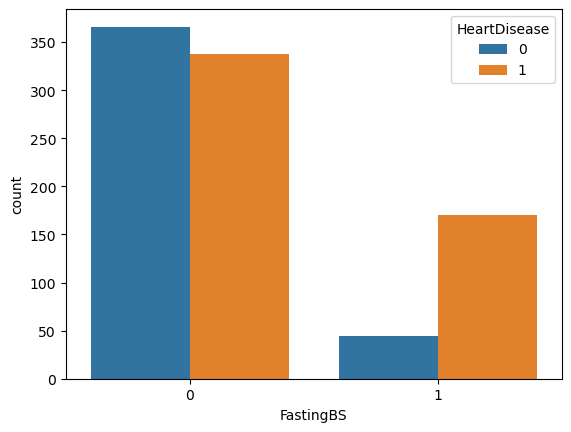

In [ ]:
# Visualize heart disease distribution by fasting blood sugar
sns.countplot(x=df['FastingBS'], hue=df['HeartDisease'])
# FastingBS > 120 mg/dl is considered abnormal (1), normal is 0
# This helps understand the relationship between blood sugar levels and heart disease
# High fasting blood sugar (diabetes indicator) may be a risk factor

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

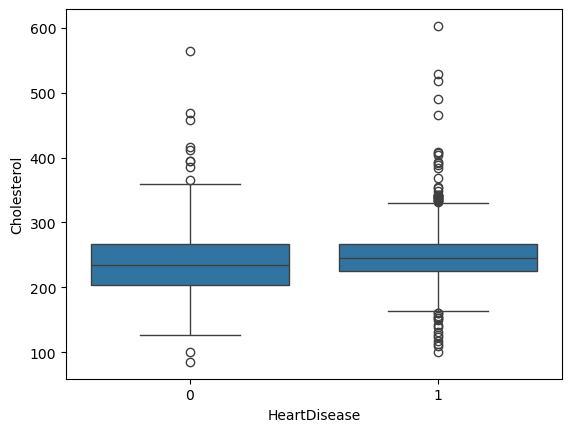

In [ ]:
# Compare cholesterol levels between patients with and without heart disease
sns.boxplot(x='HeartDisease', y='Cholesterol', data=df)
# Box plot shows:
# - Median cholesterol levels for each group
# - Interquartile range (IQR) - middle 50% of data
# - Outliers (extreme values)
# Helps visualize if cholesterol differs significantly between groups

<Axes: xlabel='HeartDisease', ylabel='Age'>

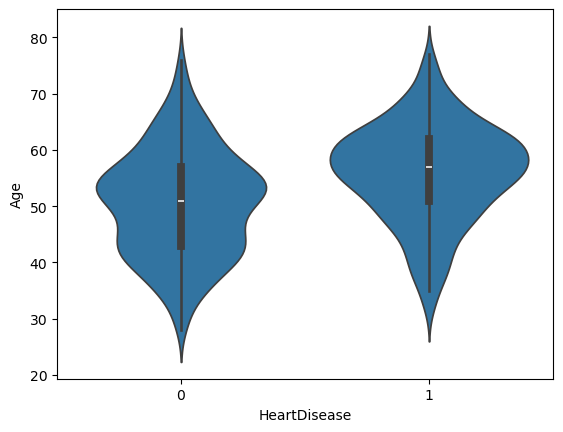

In [ ]:
# Compare age distribution between patients with and without heart disease
sns.violinplot(x='HeartDisease', y='Age', data=df)
# Violin plot combines box plot with kernel density plot
# Shows:
# - Age distribution shape for each group
# - Median and quartiles
# - Data density at different age values
# Helps visualize if age patterns differ between heart disease groups

<Axes: >

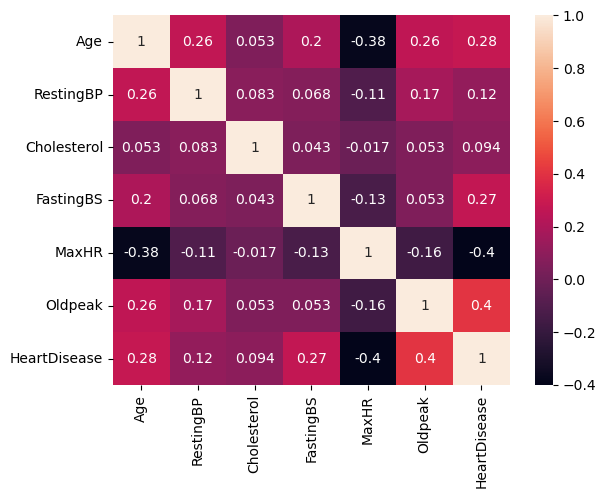

In [ ]:
# Create correlation heatmap to visualize relationships between numerical variables
sns.heatmap(df.corr(numeric_only=True), annot=True)
# Correlation heatmap shows:
# - Correlation coefficients between -1 and 1
# - 1: Perfect positive correlation
# - -1: Perfect negative correlation  
# - 0: No correlation
# annot=True displays correlation values on the heatmap
# Helps identify multicollinearity and feature relationships

# Data Preprocessing and Cleaning Section
# This section prepares the data for machine learning models

In [ ]:
# Convert categorical variables to numerical format using one-hot encoding
df_encode = pd.get_dummies(df, drop_first=True)
# One-hot encoding creates binary columns for each category
# drop_first=True avoids multicollinearity by dropping one category per feature
# For example: Sex_M (1=Male, 0=Female) instead of separate Sex_M and Sex_F columns
# This preprocessing step is required for most machine learning algorithms

In [ ]:
# Display the encoded dataset to verify the transformation
df_encode
# The dataset now has:
# - Original numerical columns (Age, RestingBP, Cholesterol, etc.)
# - New binary columns for categorical features (Sex_M, ChestPainType_ATA, etc.)
# - Total columns increased from 12 to 16 due to one-hot encoding
# All data is now in numerical format suitable for machine learning

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [ ]:
# Convert boolean values to integers (0 and 1)
df_encode = df_encode.astype(int)
# One-hot encoding creates boolean values (True/False)
# Converting to integers ensures consistency for machine learning algorithms
# Many ML libraries work better with integer/float data types

In [ ]:
# Display the final integer-encoded dataset
df_encode
# Now all values are integers (0 or 1 for categorical features)
# This format is ready for feature scaling and machine learning models
# The dataset maintains all original information but in ML-compatible format

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [ ]:
# Feature Scaling: Standardize numerical features
from sklearn.preprocessing import StandardScaler

# List of numerical columns to scale (exclude encoded categorical columns)
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# Initialize StandardScaler
scaler = StandardScaler()
# StandardScaler transforms data to have:
# - Mean = 0
# - Standard deviation = 1
# This ensures all numerical features are on the same scale
# Important for algorithms sensitive to feature magnitude (e.g., SVM, neural networks)

# Apply scaling to numerical columns
df_encode[numerical_cols] = scaler.fit_transform(df_encode[numerical_cols])
df_encode.head()
# Display first 5 rows to verify scaling
# Scaled values will be centered around 0 with most values between -3 and 3

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1
